In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('../data/DataCoSupplyChainDataset.xlsx', sheet_name='DataCoSupplyChainDataset')

print("=" * 60)
print("FORMA DEL DATASET")
print("=" * 60)
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

print("\n" + "=" * 60)
print("COLUMNAS Y TIPOS DE DATO")
print("=" * 60)
print(df.dtypes.to_string())

print("\n" + "=" * 60)
print("VALORES NULOS POR COLUMNA")
print("=" * 60)
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'Nulos': nulls, '%': nulls_pct})
print(null_df[null_df['Nulos'] > 0].to_string())

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS - COLUMNAS NUMÉRICAS")
print("=" * 60)
print(df.describe().round(2).to_string())

print("\n" + "=" * 60)
print("PRIMERAS 3 FILAS")
print("=" * 60)
print(df.head(3).to_string())
print("=" * 60)
print("ANÁLISIS DE ENTREGAS TARDÍAS")
print("=" * 60)

# Tasa general
tasa = df['Tardio(1/0)'].mean() * 100
print(f"\nTasa global de entregas tardías: {tasa:.2f}%")

# Por modo de envío
print("\n--- Por Shipping Mode ---")
print(df.groupby('Shipping Mode')['Tardio(1/0)'].agg(['mean','count'])
      .rename(columns={'mean':'% tardías','count':'órdenes'})
      .assign(**{'% tardías': lambda x: (x['% tardías']*100).round(2)})
      .sort_values('% tardías', ascending=False).to_string())

# Por mercado
print("\n--- Por Market ---")
print(df.groupby('Market')['Tardio(1/0)'].agg(['mean','count'])
      .rename(columns={'mean':'% tardías','count':'órdenes'})
      .assign(**{'% tardías': lambda x: (x['% tardías']*100).round(2)})
      .sort_values('% tardías', ascending=False).to_string())

# Por departamento
print("\n--- Por Department ---")
print(df.groupby('Department Name')['Tardio(1/0)'].agg(['mean','count'])
      .rename(columns={'mean':'% tardías','count':'órdenes'})
      .assign(**{'% tardías': lambda x: (x['% tardías']*100).round(2)})
      .sort_values('% tardías', ascending=False).to_string())

# Por Delivery Status detallado
print("\n--- Distribución Delivery Status ---")
print(df['Delivery Status'].value_counts(normalize=True).mul(100).round(2).to_string())

print("\n--- Distribución Shipping Mode ---")
print(df['Shipping Mode'].value_counts().to_string())

FORMA DEL DATASET
Filas: 180,519
Columnas: 33

COLUMNAS Y TIPOS DE DATO
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Name                        str
Department Name                      str
Latitude                         float64
Longitude                        float64
Market                               str
Order City                           str
Order Country                        str
order date (DateOrders)           object
Order Item Discount              float64
Order Item Discount Rate         float64
Order Item Product Price         float64
Order Item Profit Ratio          float64
Order Item Quantity                int64
Sales                            float64
Order Item Total                 float64
Order Profit Per Order    

In [4]:
print("=" * 60)
print("ANÁLISIS FINANCIERO")
print("=" * 60)

# Impacto financiero de tardanzas
print("\n--- Beneficio promedio: tardías vs a tiempo ---")
financiero = df.groupby('Tardio(1/0)').agg(
    beneficio_promedio=('Benefit per order', 'mean'),
    ventas_promedio=('Sales', 'mean'),
    profit_ratio_promedio=('Order Item Profit Ratio', 'mean'),
    ordenes=('Sales', 'count')
).round(2)
financiero.index = ['A tiempo', 'Tardía']
print(financiero.to_string())

# Impacto por Shipping Mode
print("\n--- Beneficio promedio por Shipping Mode ---")
print(df.groupby('Shipping Mode').agg(
    beneficio_promedio=('Benefit per order', 'mean'),
    ventas_totales=('Sales', 'sum'),
    ordenes=('Sales', 'count')
).round(2).sort_values('beneficio_promedio', ascending=False).to_string())

# Órdenes con pérdida
perdidas = df[df['Benefit per order'] < 0]
print(f"\n--- Órdenes con pérdida ---")
print(f"Total: {len(perdidas):,} ({len(perdidas)/len(df)*100:.2f}%)")
print(f"Pérdida promedio por orden: ${perdidas['Benefit per order'].mean():.2f}")
print(f"Pérdida total acumulada: ${perdidas['Benefit per order'].sum():,.2f}")

print("\n--- Órdenes con pérdida por Shipping Mode ---")
print(df[df['Benefit per order'] < 0]['Shipping Mode'].value_counts().to_string())

# Top 10 categorías por ventas totales
print("\n--- Top 10 Categorías por Ventas Totales ---")
print(df.groupby('Category Name').agg(
    ventas_totales=('Sales', 'sum'),
    tardias_pct=('Tardio(1/0)', 'mean')
).round(2)
.assign(tardias_pct=lambda x: (x['tardias_pct']*100).round(2))
.sort_values('ventas_totales', ascending=False)
.head(10).to_string())

ANÁLISIS FINANCIERO

--- Beneficio promedio: tardías vs a tiempo ---
          beneficio_promedio  ventas_promedio  profit_ratio_promedio  ordenes
A tiempo               22.50           204.35                   0.12    77119
Tardía                 21.59           203.34                   0.12   103400

--- Beneficio promedio por Shipping Mode ---
                beneficio_promedio  ventas_totales  ordenes
Shipping Mode                                              
First Class                  23.12      5674369.76    27814
Standard Class               22.00     22022391.88   107752
Second Class                 21.31      7145444.82    35216
Same Day                     20.85      1942528.56     9737

--- Órdenes con pérdida ---
Total: 33,784 (18.71%)
Pérdida promedio por orden: $-114.95
Pérdida total acumulada: $-3,883,547.35

--- Órdenes con pérdida por Shipping Mode ---
Shipping Mode
Standard Class    20318
Second Class       6529
First Class        5102
Same Day           1835

--- 

Matplotlib is building the font cache; this may take a moment.


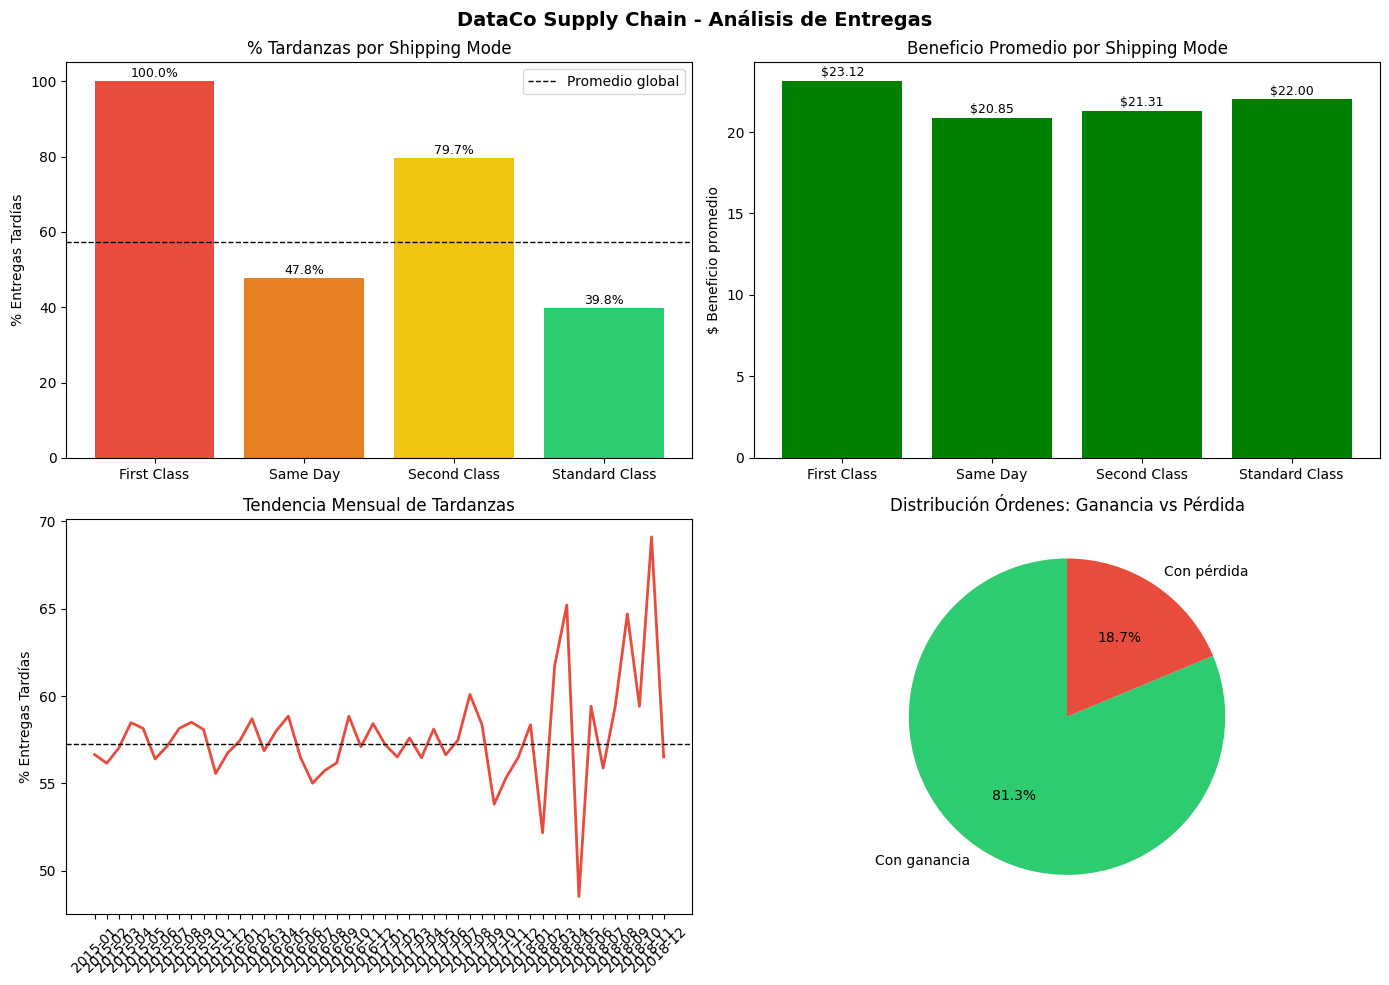

Gráfica guardada en outputs/


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Convertir fechas
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], 
                                   format='mixed', dayfirst=False)
df['año_mes'] = df['order_date'].dt.to_period('M')

# Tendencia mensual de tardanzas
tendencia = df.groupby('año_mes').agg(
    tasa_tardia=('Tardio(1/0)', 'mean'),
    ordenes=('Sales', 'count')
).reset_index()
tendencia['año_mes_str'] = tendencia['año_mes'].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DataCo Supply Chain - Análisis de Entregas', 
             fontsize=14, fontweight='bold')

# Gráfica 1 — Tasa tardanza por Shipping Mode
modos = df.groupby('Shipping Mode')['Tardio(1/0)'].mean() * 100
axes[0,0].bar(modos.index, modos.values, 
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'])
axes[0,0].set_title('% Tardanzas por Shipping Mode')
axes[0,0].set_ylabel('% Entregas Tardías')
axes[0,0].axhline(y=57.28, color='black', linestyle='--', 
                   linewidth=1, label='Promedio global')
axes[0,0].legend()
for i, v in enumerate(modos.values):
    axes[0,0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9)

# Gráfica 2 — Beneficio promedio por Shipping Mode
beneficio = df.groupby('Shipping Mode')['Benefit per order'].mean()
colores = ['green' if x > 0 else 'red' for x in beneficio.values]
axes[0,1].bar(beneficio.index, beneficio.values, color=colores)
axes[0,1].set_title('Beneficio Promedio por Shipping Mode')
axes[0,1].set_ylabel('$ Beneficio promedio')
for i, v in enumerate(beneficio.values):
    axes[0,1].text(i, v + 0.3, f'${v:.2f}', ha='center', fontsize=9)

# Gráfica 3 — Tendencia mensual tardanzas
axes[1,0].plot(tendencia['año_mes_str'], 
               tendencia['tasa_tardia'] * 100, 
               color='#e74c3c', linewidth=2)
axes[1,0].set_title('Tendencia Mensual de Tardanzas')
axes[1,0].set_ylabel('% Entregas Tardías')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=57.28, color='black', linestyle='--', linewidth=1)

# Gráfica 4 — Órdenes con pérdida vs ganancia
labels = ['Con ganancia', 'Con pérdida']
sizes = [len(df[df['Benefit per order'] >= 0]), 
         len(df[df['Benefit per order'] < 0])]
colors = ['#2ecc71', '#e74c3c']
axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
              startangle=90)
axes[1,1].set_title('Distribución Órdenes: Ganancia vs Pérdida')

plt.tight_layout()
plt.savefig('../outputs/analisis_entregas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada en outputs/")
